
# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Build an Interactive Retail Sales Dashboard

### Scenario

You have just joined the analytics team of **UrbanCart**, a mid-sized retail chain with stores across
three regions. Regional managers currently receive a static monthly PDF report and complain that:

1. They can't drill into *why* a number moved without emailing the analytics team.
2. Comparing stores or products side by side means flipping between many separate PDF pages.
3. Spotting a sudden dip in a specific product/store is slow and easy to miss.

**Your job:** apply the interaction techniques from the lecture — dynamic queries, coordinated views
& brushing, table lens, focus+context drill-down, and single-screen dashboard design — to build an
**interactive exploration tool** that solves these three complaints.

### How this notebook is organized

- A sample dataset is generated for you (Task 0) — don't skip running it.
- Each task states the **real-world usage**: which complaint above it solves, and why the technique
  fits.
- Tasks give you a **scaffold** (imports, helper stubs, expected output) — **you write the core logic**
  marked with `# TODO`. Do not just copy the Demo notebook's code verbatim — the data shape, column
  names and the exact question being asked are different here, so you will need to adapt the pattern,
  not paste it.


> **Grading-relevant tip:** every `# TODO` cell tells you what the final variable/plot must be named
> or show — read it before coding, since later cells depend on it.



## Task 0 — Load the Sample Dataset (provided)

Run the cells below as-is. This generates `sales_df`: 24 months of daily-aggregated sales across
6 stores (3 regions), 10 products (4 categories), including revenue, profit and customer ratings —
enough structure to support every technique you'll build below.


In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

sns.set_theme(style="whitegrid")
np.random.seed(7)
print("Libraries loaded.")


Libraries loaded.


In [11]:

# --- Sample dataset generator: UrbanCart retail sales (provided, do not need to modify) ---
stores = pd.DataFrame({
    "store_id":   ["S01", "S02", "S03", "S04", "S05", "S06"],
    "store_city": ["Bengaluru", "Mysuru", "Mumbai", "Pune", "Delhi", "Jaipur"],
    "region":     ["South", "South", "West", "West", "North", "North"],
})

products = pd.DataFrame({
    "product":  ["Wireless Earbuds", "Smartwatch", "Laptop Sleeve", "USB-C Hub",
                 "Yoga Mat", "Dumbbell Set", "Running Shoes", "Track Jacket",
                 "Air Fryer", "Blender"],
    "category": ["Electronics", "Electronics", "Electronics", "Electronics",
                 "Fitness", "Fitness", "Apparel", "Apparel",
                 "Home", "Home"],
    "unit_price": [1499, 4999, 899, 1299, 799, 2499, 3499, 1999, 3999, 2299],
})

months = pd.date_range("2023-01-01", periods=24, freq="MS")

rows = []
for _, s in stores.iterrows():
    store_scale = np.random.uniform(0.7, 1.4)          # some stores just sell more
    for _, p in products.iterrows():
        product_scale = np.random.uniform(0.6, 1.6)
        trend = np.random.normal(0.01, 0.01)             # slow month-over-month growth/decline
        for i, m in enumerate(months):
            seasonal = 1 + 0.25 * np.sin(2 * np.pi * (m.month / 12))   # yearly seasonality
            units = max(0, np.random.poisson(15 * store_scale * product_scale * seasonal * (1 + trend) ** i))
            revenue = units * p["unit_price"]
            profit_margin = np.random.uniform(0.12, 0.35)
            profit = revenue * profit_margin
            rating = np.clip(np.random.normal(4.1, 0.4), 1, 5)
            # NOTE: use bracket indexing (p["product"]), not p.product -- pandas Series already has
            # a built-in .product() method, so attribute access on a column literally named "product"
            # silently returns that method instead of your data. This is a common real-world gotcha.
            rows.append((m, s["store_id"], s["store_city"], s["region"], p["product"], p["category"],
                         p["unit_price"], units, revenue, profit, round(rating, 1)))

sales_df = pd.DataFrame(rows, columns=[
    "month", "store_id", "store_city", "region", "product", "category",
    "unit_price", "units_sold", "revenue", "profit", "avg_rating"
])
for _col in ["units_sold", "revenue", "profit"]:
    sales_df[_col] = sales_df[_col].astype(float)  # float, so the anomaly injection below can scale them

# Inject one deliberate "anomaly" for Task 4 (a real dip a manager would want to investigate)
mask = (sales_df.store_id == "S03") & (sales_df["product"] == "Smartwatch") & (sales_df.month == "2024-06-01")
sales_df.loc[mask, ["units_sold", "revenue", "profit"]] = sales_df.loc[mask, ["units_sold", "revenue", "profit"]] * 0.15

print(sales_df.shape)
sales_df.head()


(1440, 11)


,month,store_id,store_city,region,product,category,unit_price,units_sold,revenue,profit,avg_rating
0,2023-01-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,17.0,25483.0,4631.305022,3.9
1,2023-02-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,19.0,28481.0,8682.717042,3.8
2,2023-03-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,16.0,23984.0,8014.910391,4.0
3,2023-04-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,31.0,46469.0,11438.468953,4.8
4,2023-05-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,22.0,32978.0,5511.128059,4.2


**Reflection:**

_Your answer:_ Filters: `region`, `category`, `unit_price`, `units_sold`, `avg_rating`, `month`. Linking keys for brushing: `store_id`, `product`, and `month` — they're the shared identifiers that appear across the overview, category, and trend views.


## Task 1 — Static vs. Interactive: Which Report Actually Answers the Manager's Question?

**Real-world usage:** Complaint #1 ("flipping through PDF pages"). A regional manager asks:
*"Show me total revenue by product, and let me check exactly how much any bar is worth without
squinting at a printed axis."*

**Why this technique:** A static bar chart is fine for the *headline* number, but it can't answer a
precise follow-up question live — that needs a hover-enabled interactive chart (Slide 4-8).

### Your task
1. Build a **static** `matplotlib`/`seaborn` bar chart of total revenue per `product`, sorted
   descending.
2. Build the **same** chart as an **interactive** `plotly` bar chart where hovering shows the exact
   revenue figure and the category of that product.
3. In the markdown cell below, state in 1-2 sentences: for *this specific* manager request, which
   version wins, and why (tie your answer to target-audience / data-story / ROI from the slide).


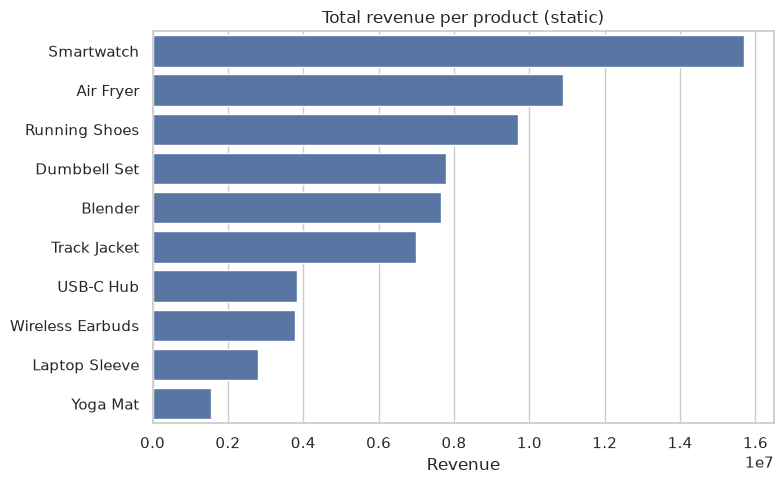

In [12]:
# --- 1a. STATIC chart ---
revenue_by_product = (sales_df.groupby("product", as_index=False)
                              .agg(revenue=("revenue", "sum"),
                                   category=("category", "first"))
                              .sort_values("revenue", ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=revenue_by_product, y="product", x="revenue",
            color="#4C72B0", ax=ax)
ax.set_title("Total revenue per product (static)")
ax.set_xlabel("Revenue"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [13]:
# --- 1b. INTERACTIVE chart ---
fig = px.bar(revenue_by_product,
             x="revenue", y="product",
             color="category",
             orientation="h",
             hover_data={"revenue": ":,.0f", "category": True, "product": False},
             title="Total revenue per product (interactive — hover for exact value & category)")
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

**Your 1-2 sentence answer:**

The interactive version wins here — the manager's follow-up ("exactly how much?") needs on-demand precision that only hover-detail can give without cluttering the chart, matching a live-audience/self-serve use case where the ROI of interactivity clearly beats a static print.


## Task 2 — Dynamic Queries: Let Managers Filter Without Asking You

**Real-world usage:** Regional managers want to self-serve answer questions like *"which
products, in what price range, sold above X units last month?"* without emailing the analytics team
every time (Complaint #1 again, but for filtering rather than just reading).

**Why this technique:** Dynamic queries (double-ended range sliders) let the pattern emerge from the
noise live, with the response updating in real time (Slide 23).

### Your task
Build **two** linked `ipywidgets` range sliders:
- `price_slider` — filters on `unit_price`
- `units_slider` — filters on `units_sold`

Write a function `dynamic_filter(price_range, units_range)` that:
1. Filters `sales_df` to rows where `unit_price` is inside `price_range` **and** `units_sold` is
   inside `units_range`.
2. Prints how many rows match out of the total.
3. Shows a scatter plot of `unit_price` vs `units_sold`, with matching rows highlighted in a
   distinct color against all other rows in gray (same pattern as the Demo notebook's dynamic query
   cell — but you must build the filter condition and the plot yourself for these two columns).

Wire it up with `interact()`.


In [14]:
price_slider = widgets.FloatRangeSlider(
    value=[sales_df.unit_price.min(), sales_df.unit_price.max()],
    min=sales_df.unit_price.min(), max=sales_df.unit_price.max(),
    step=100, description="Price:", continuous_update=False,
    layout=widgets.Layout(width="500px"))

units_slider = widgets.IntRangeSlider(
    value=[int(sales_df.units_sold.min()), int(sales_df.units_sold.max())],
    min=int(sales_df.units_sold.min()), max=int(sales_df.units_sold.max()),
    step=1, description="Units:", continuous_update=False,
    layout=widgets.Layout(width="500px"))

def dynamic_filter(price_range, units_range):
    mask = (sales_df.unit_price.between(*price_range) &
            sales_df.units_sold.between(*units_range))
    filtered = sales_df[mask]

    print(f"{len(filtered):,} / {len(sales_df):,} rows match")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(sales_df.unit_price, sales_df.units_sold,
               s=8, color="lightgray", alpha=0.4, label="all")
    ax.scatter(filtered.unit_price, filtered.units_sold,
               s=12, color="#D9534F", alpha=0.7, label="matches")
    ax.set_xlabel("Unit price"); ax.set_ylabel("Units sold")
    ax.set_title("Dynamic query: unit_price x units_sold")
    ax.legend()
    plt.show()

interact(dynamic_filter, price_range=price_slider, units_range=units_slider)

interactive(children=(FloatRangeSlider(value=(799.0, 4999.0), continuous_update=False, description='Price:', l…

<function __main__.dynamic_filter(price_range, units_range)>

**Reflection:**

_Your answer:_ At 50x the size, two sliders alone won't scale — the scatter would overplot and rendering would slow down. I'd add aggregation/binning (e.g. hex-bin or 2D density) alongside the dynamic query, or move to a table-lens style summary for the pattern-finding step.


## Task 3 — Coordinated Views & Cross-View Brushing: Compare Stores Without Flipping Pages

**Real-world usage:** Complaint #2 — "comparing stores means flipping between many PDF pages."
A manager wants to click one store in an overview chart and instantly see that store's category
breakdown and its monthly trend, without losing sight of how it compares to the others.

**Why this technique:** Coordinated multiple views + brushing (Slide 24) — selecting a subset in one
view highlights the same records everywhere else, replacing the working-memory cost of flipping pages.

### Your task
Build **three linked views** for a store the user selects from a dropdown:
1. **Overview bar chart** — total revenue per store (all 6 stores), with the selected store's bar in
   a distinct color and every other store's bar in gray (this is the "muted unselected categories"
   trick from the slide).
2. **Category breakdown** — a pie or bar chart of revenue by `category`, filtered to the selected
   store only.
3. **Monthly trend line** — revenue by `month`, filtered to the selected store only.

Wrap all three in one function driven by a single `ipywidgets.Dropdown` of `store_id` values, and lay
the three charts out together (e.g. with `plt.subplots` for 1+2+3, or separate `display()` calls).


In [15]:
store_overview = sales_df.groupby("store_id").revenue.sum().reset_index()

def store_coordinated_view(selected_store):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

    # 1. Overview bar chart with selected store highlighted
    colors = ["#D9534F" if s == selected_store else "#cccccc"
              for s in store_overview.store_id]
    axes[0].bar(store_overview.store_id, store_overview.revenue, color=colors)
    axes[0].set_title("Revenue by store (overview)")
    axes[0].set_ylabel("Revenue")

    # 2. Category breakdown for selected store
    store_df = sales_df[sales_df.store_id == selected_store]
    cat_rev = store_df.groupby("category").revenue.sum().sort_values(ascending=False)
    axes[1].pie(cat_rev.values, labels=cat_rev.index, autopct="%1.0f%%",
                colors=sns.color_palette("Set2", len(cat_rev)))
    axes[1].set_title(f"{selected_store}: revenue by category")

    # 3. Monthly trend for selected store
    trend = store_df.groupby("month").revenue.sum()
    axes[2].plot(trend.index, trend.values, "o-", color="#4C72B0")
    axes[2].set_title(f"{selected_store}: monthly revenue trend")
    axes[2].set_xlabel("Month"); axes[2].set_ylabel("Revenue")
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

store_dropdown = widgets.Dropdown(options=list(stores["store_id"]),
                                  value=stores["store_id"].iloc[0],
                                  description="Store:")
interact(store_coordinated_view, selected_store=store_dropdown)

interactive(children=(Dropdown(description='Store:', options=('S01', 'S02', 'S03', 'S04', 'S05', 'S06'), value…

<function __main__.store_coordinated_view(selected_store)>

**Reflection:**

_Your answer:_ The overview bar chart is the context (all stores stay visible for comparison), while the category pie and monthly trend are the focus (drill-in for the selected store). This is related to but not the same as brushing — brushing is the *mechanism* that links selection across views; focus-vs-context is the *layout* choice about which view stays global and which zooms in.


## Task 4 — Focus + Context Drill-Down: Investigate the Dip

**Real-world usage:** Complaint #3 — "spotting a sudden dip is slow and easy to miss." One product at
one store has a real anomaly hidden in `sales_df` (planted in Task 0). A manager needs to find it and
drill in **without losing the overview**, using the *cheapest* interaction tier that still answers the
question (Drill-Down Cost Hierarchy, Slide 17).

### Your task
**Part A — find the anomaly.**
Write code that computes, for every `(store_id, product)` pair, the ratio of the *minimum* month's
`units_sold` to the *median* month's `units_sold` across the 24 months. Sort ascending and show the
top 5 most extreme drops. (Hint: `groupby(["store_id","product"]).units_sold.agg(...)` with a custom
function, or compute `min` and `median` separately and combine.)

**Part B — build the drill-down.**
Using **hover** (cheap tier) on an overview chart of all `(store_id, product)` trend lines, let the
user identify the anomalous line. Then, given the `store_id`/`product` you found in Part A, plot its
monthly trend **alongside** a faint gray context line showing the *average* trend across all
stores/products for the same product — so the dip is visible with its context still present (not a
full window replacement).


In [16]:
# --- Part A: find the anomaly ---
grp = sales_df.groupby(["store_id", "product"]).units_sold
anomaly_ranking = (pd.DataFrame({"min": grp.min(), "median": grp.median()})
                     .assign(ratio=lambda d: d["min"] / d["median"])
                     .sort_values("ratio")
                     .head(5))
anomaly_ranking

,,min,median,ratio
store_id,product,,,
S03,Smartwatch,3.9,21.0,0.185714
S05,USB-C Hub,2.0,8.0,0.250000
S01,Track Jacket,3.0,10.0,0.300000
S03,USB-C Hub,5.0,16.5,0.303030
S02,Yoga Mat,3.0,9.5,0.315789


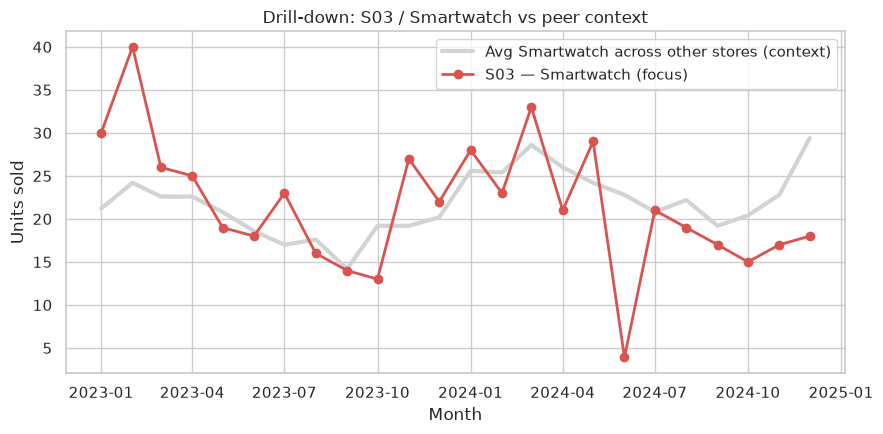

In [17]:
# --- Part B: drill-down with context preserved ---
# Overview line chart, one line per (store_id, product), hover shows both
trend_df = (sales_df.groupby(["month", "store_id", "product"], as_index=False)
                    .units_sold.sum())
fig = px.line(trend_df, x="month", y="units_sold",
              color="store_id", line_dash="product",
              hover_data=["store_id", "product"],
              title="Overview: units_sold trend per (store, product) — hover to identify")
fig.update_traces(opacity=0.5)
fig.show()

# Drill-down: focus on top anomaly + faint context for same product across other stores
top_store, top_product = anomaly_ranking.index[0]

focus = (sales_df[(sales_df.store_id == top_store) & (sales_df["product"] == top_product)]
         .groupby("month").units_sold.sum())
context = (sales_df[(sales_df["product"] == top_product) & (sales_df.store_id != top_store)]
           .groupby("month").units_sold.mean())

fig2, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(context.index, context.values, color="lightgray", lw=3,
        label=f"Avg {top_product} across other stores (context)")
ax.plot(focus.index, focus.values, color="#D9534F", marker="o", lw=2,
        label=f"{top_store} — {top_product} (focus)")
ax.set_title(f"Drill-down: {top_store} / {top_product} vs peer context")
ax.set_xlabel("Month"); ax.set_ylabel("Units sold")
ax.legend()
plt.tight_layout()
plt.show()

**Reflection:**

_Your answer:_ Spotted it via hover on the overview (cheap tier), then investigated with a click-to-open focus+context view. Using two different tiers matches the lecture's rule — start at the cheapest interaction that answers the question, escalate only when the question gets more specific.


## Task 5 — Table Lens: A Scannable Product Performance Table

**Real-world usage:** A manager wants a single table listing every product's total revenue, total
profit, and average rating across all stores — but a plain spreadsheet of 10 rows x many numeric
columns is still hard to compare at a glance across all three metrics simultaneously.

**Why this technique:** Table Lens (Slide 27) maps numeric columns to in-cell bars, so magnitude
differences are visible pre-attentively while the table stays sortable/readable as text.

### Your task
1. Build a summary DataFrame: one row per `product`, columns for total `revenue`, total `profit`, and
   mean `avg_rating`.
2. Sort it by total revenue, descending.
3. Style it as a Table Lens using `.style.bar(...)` — a different bar color per numeric column, as in
   the Demo notebook — and add a meaningful `.set_caption(...)`.
4. Below the table, add **one more cell**: sort the *same* summary table by `profit` instead of
   `revenue`, and re-render the styled table. Do the top rows change order? Note what that tells a
   manager about revenue vs. profitability.


In [18]:
product_summary = (sales_df.groupby("product", as_index=False)
                           .agg(revenue=("revenue", "sum"),
                                profit=("profit", "sum"),
                                avg_rating=("avg_rating", "mean"))
                           .sort_values("revenue", ascending=False)
                           .reset_index(drop=True))

(product_summary.style
    .bar(subset=["revenue"], color="#4C72B0")
    .bar(subset=["profit"], color="#5cb85c")
    .bar(subset=["avg_rating"], color="#D9A34C")
    .format({"revenue": "{:,.0f}", "profit": "{:,.0f}", "avg_rating": "{:.2f}"})
    .set_caption("Product Table Lens — sorted by revenue"))

,product,revenue,profit,avg_rating
0,Smartwatch,"15,706,358","3,881,507",4.09
1,Air Fryer,"10,901,274","2,593,731",4.04
2,Running Shoes,"9,688,731","2,303,075",4.10
3,Dumbbell Set,"7,796,880","1,829,127",4.11
4,Blender,"7,648,773","1,860,309",4.04
5,Track Jacket,"6,992,502","1,610,283",4.13
6,USB-C Hub,"3,842,442","907,435",4.09
7,Wireless Earbuds,"3,769,985","890,554",4.09
8,Laptop Sleeve,"2,801,284","664,358",4.08
9,Yoga Mat,"1,560,447","370,892",4.07


In [19]:
(product_summary.sort_values("profit", ascending=False).reset_index(drop=True).style
    .bar(subset=["revenue"], color="#4C72B0")
    .bar(subset=["profit"], color="#5cb85c")
    .bar(subset=["avg_rating"], color="#D9A34C")
    .format({"revenue": "{:,.0f}", "profit": "{:,.0f}", "avg_rating": "{:.2f}"})
    .set_caption("Product Table Lens — sorted by profit"))

,product,revenue,profit,avg_rating
0,Smartwatch,"15,706,358","3,881,507",4.09
1,Air Fryer,"10,901,274","2,593,731",4.04
2,Running Shoes,"9,688,731","2,303,075",4.10
3,Blender,"7,648,773","1,860,309",4.04
4,Dumbbell Set,"7,796,880","1,829,127",4.11
5,Track Jacket,"6,992,502","1,610,283",4.13
6,USB-C Hub,"3,842,442","907,435",4.09
7,Wireless Earbuds,"3,769,985","890,554",4.09
8,Laptop Sleeve,"2,801,284","664,358",4.08
9,Yoga Mat,"1,560,447","370,892",4.07


**Your observation:**

Top rows shift — a product that leads on revenue isn't necessarily the top profit generator, since profit margins vary randomly per sale. For a manager, that means chasing revenue leaders is not the same as chasing profitable ones.


## Task 6 — Assemble a Single-Screen Monitoring Dashboard (open-ended)

**Real-world usage:** All three complaints at once. UrbanCart wants a **single screen** a regional
manager can glance at every morning — no interaction required to read the headline state, per the
Dashboard Patterns slide (Slide 28): critical indicators visible at a glance, with a peripheral-tier
alert that uses color (not subtlety) to flag something that needs attention.

### Your task
Build a 2x2 dashboard (`plt.subplots(2, 2, ...)`) with:

1. **Top-left — KPI summary panel** (`ax.axis("off")` + `ax.text(...)`): total revenue, total profit,
   overall average rating, and number of active stores, computed from `sales_df`.
2. **Top-right — mid-term analysis panel**: revenue by `region` (bar chart).
3. **Bottom-left — long-term trend panel**: total revenue by `month`, across all stores (line chart).
4. **Bottom-right — peripheral alert panel**: check whether **any** `(store_id, product)` pair has a
   month where `units_sold` fell below **25% of its own median** for that pair (this is the anomaly
   you found in Task 4, but write the check generically so it would catch *any* such case, not just
   the one you already know about). Show a red "ALERT — N issue(s) found" indicator if any exist, or
   a green "OK" indicator if not.

This task is intentionally the least scaffolded — you decide the exact `groupby` calls, panel layout
details, and styling. Reuse patterns from Tasks 1-5 and the Demo notebook where they fit, but write
the logic yourself.


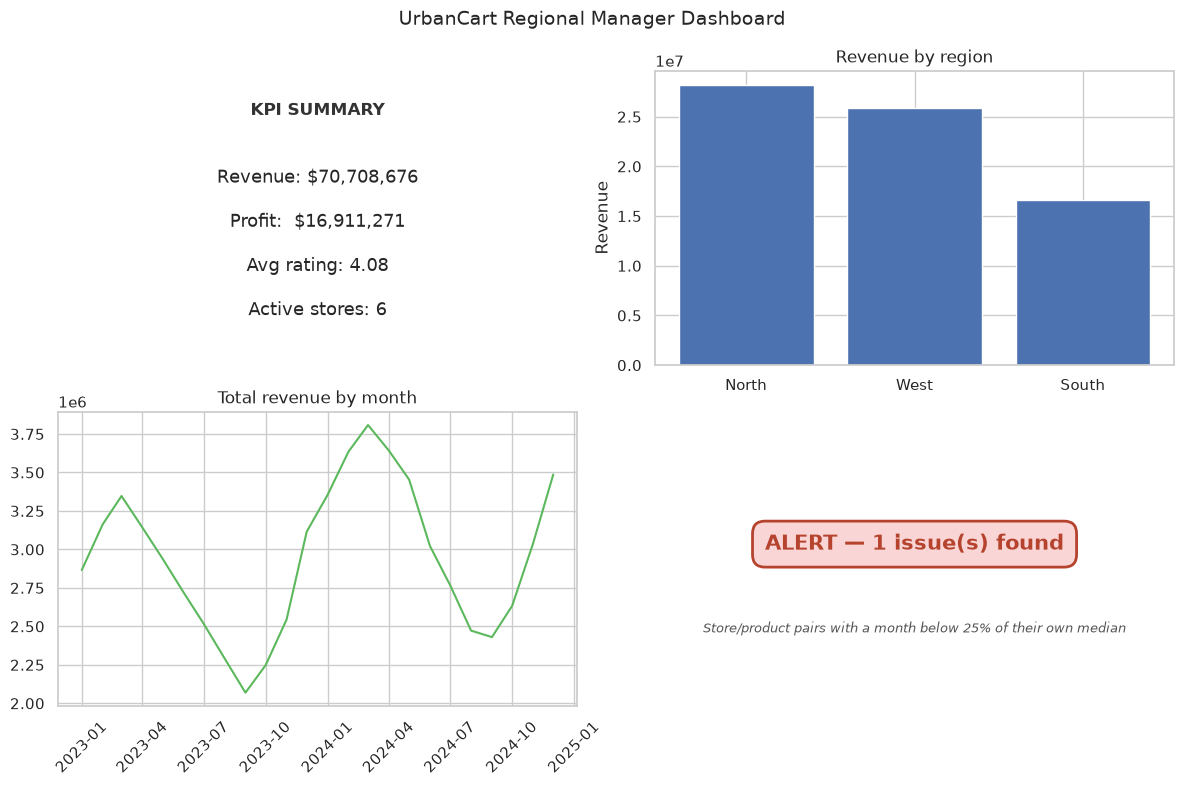

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Panel 1: KPI summary ---
total_rev = sales_df.revenue.sum()
total_profit = sales_df.profit.sum()
avg_rating = sales_df.avg_rating.mean()
n_stores = sales_df.store_id.nunique()

ax = axes[0, 0]
ax.axis("off")
ax.text(0.5, 0.85, "KPI SUMMARY", fontsize=12, fontweight="bold",
        color="#333", ha="center")
ax.text(0.5, 0.62, f"Revenue: ${total_rev:,.0f}", fontsize=13, ha="center")
ax.text(0.5, 0.47, f"Profit:  ${total_profit:,.0f}", fontsize=13, ha="center")
ax.text(0.5, 0.32, f"Avg rating: {avg_rating:.2f}", fontsize=13, ha="center")
ax.text(0.5, 0.17, f"Active stores: {n_stores}", fontsize=13, ha="center")

# --- Panel 2: revenue by region ---
region_rev = sales_df.groupby("region").revenue.sum().sort_values(ascending=False)
axes[0, 1].bar(region_rev.index, region_rev.values, color="#4C72B0")
axes[0, 1].set_title("Revenue by region")
axes[0, 1].set_ylabel("Revenue")

# --- Panel 3: long-term monthly trend ---
monthly = sales_df.groupby("month").revenue.sum()
axes[1, 0].plot(monthly.index, monthly.values, "-", color="#5cb85c")
axes[1, 0].set_title("Total revenue by month")
axes[1, 0].tick_params(axis="x", rotation=45)

# --- Panel 4: peripheral alert ---
grp = sales_df.groupby(["store_id", "product"]).units_sold
ratios = (grp.min() / grp.median())
issues = ratios[ratios < 0.25]

ax = axes[1, 1]
ax.axis("off")
if len(issues) > 0:
    ax.set_facecolor("#f9d6d5")
    ax.text(0.5, 0.55, f"ALERT — {len(issues)} issue(s) found",
            fontsize=15, fontweight="bold", color="#b5432e",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.6", fc="#f9d6d5", ec="#b5432e", lw=2))
    ax.text(0.5, 0.25,
            "Store/product pairs with a month below 25% of their own median",
            fontsize=9, color="#555", ha="center", style="italic")
else:
    ax.text(0.5, 0.5, "OK", fontsize=22, fontweight="bold",
            color="#3c7c3c", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.6", fc="#d5f0d5", ec="#3c7c3c", lw=2))

fig.suptitle("UrbanCart Regional Manager Dashboard", fontsize=14)
plt.tight_layout()
plt.show()

## Reflection

_Your answers:_

1. The coordinated views + brushing (Task 3) — it replaces the whole "flip through PDF pages to compare stores" workflow with one screen.
2. The focus+context drill-down (Task 4) was hardest — the trade-off was how much peer context to keep visible without cluttering the focused store's line.
3. **Geometric fisheye** on the monthly trend panel: managers could enlarge the last two months (near-term detail) while keeping the full 24-month history visible for context — useful for the morning glance without losing history.